<a href="https://colab.research.google.com/github/RogerVin1/Assigment1-DeepLearnig/blob/main/assigment1DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [59]:
import copy, pickle, time, zipfile, urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from scipy import ndimage
from scipy.stats import spearmanr
from skimage.draw import ellipse
from skimage.measure import regionprops
from skimage.segmentation import watershed

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Parte 0 — Teste unitário sintético

Imagens 128×128 com 5 a 20 elipses de tamanhos variados, muitas encostadas, com ruído e contraste variáveis. A máscara de instâncias vem de graça do gerador. Serve para validar o pipeline inteiro (dados → U-Net → métricas) antes de tocar nos dados reais.

In [60]:
def gerar_amostra(size=128, min_elipses=5, max_elipses=20, raio_min=6, raio_max=20,
                  fracao_minima_visivel=0.55, rng=None):
    """Imagem sintética em tons de cinza e sua máscara de instâncias (0 = fundo, k = k-ésima elipse).
       Elipses podem se encostar; uma elipse só entra se pelo menos `fracao_minima_visivel` dela ficar visível."""
    rng = rng or np.random.default_rng()
    inst_mask = np.zeros((size, size), dtype=np.int32)
    n_elipses = int(rng.integers(min_elipses, max_elipses + 1))
    colocadas = 0

    for _ in range(12 * n_elipses):
        if colocadas == n_elipses:
            break

        cy, cx = rng.integers(raio_min, size - raio_min, size=2)
        ry, rx = rng.integers(raio_min, raio_max + 1, size=2)
        rr, cc = ellipse(cy, cx, ry, rx, shape=(size, size), rotation=rng.uniform(0, np.pi))

        candidata = np.zeros((size, size), dtype=bool)
        candidata[rr, cc] = True
        visivel = candidata & (inst_mask == 0)

        if candidata.sum() == 0 or visivel.sum() / candidata.sum() < fracao_minima_visivel:
            continue

        colocadas += 1
        inst_mask[visivel] = colocadas

    return renderizar_imagem(inst_mask, rng), inst_mask

def renderizar_imagem(inst_mask, rng):
    """Fundo escuro, um brilho por instância e ruído gaussiano, com níveis sorteados por imagem."""
    imagem = np.full(inst_mask.shape, rng.uniform(0.05, 0.20), dtype=np.float32)

    for k in range(1, inst_mask.max() + 1):
        imagem[inst_mask == k] = rng.uniform(0.45, 0.95)

    imagem += rng.normal(0, rng.uniform(0.02, 0.12), size=imagem.shape)
    return np.clip(imagem, 0, 1).astype(np.float32)

def colorir_instancias(inst_mask, rng=None):
    """Imagem RGB com uma cor aleatória por instância e fundo preto, só para visualização."""
    rng = rng or np.random.default_rng(0)
    rgb = np.zeros((*inst_mask.shape, 3), dtype=np.float32)

    for k in range(1, inst_mask.max() + 1):
        rgb[inst_mask == k] = rng.uniform(0.3, 1.0, size=3)

    return rgb

def ids_objetos(inst_mask):
    return np.unique(inst_mask[inst_mask != 0])

def n_objetos(inst_mask):
    return len(ids_objetos(inst_mask))

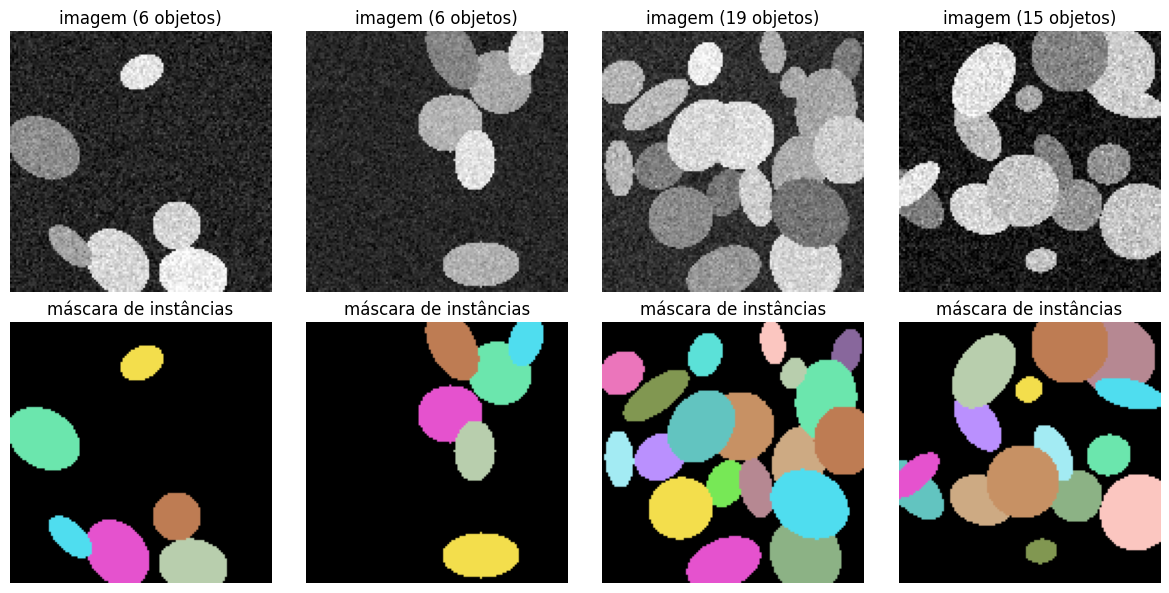

objetos por imagem (200 amostras): mín 5 | média 12.2 | máx 20


In [61]:
rng = np.random.default_rng(42)
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for col in range(4):
    imagem, inst_mask = gerar_amostra(rng=rng)
    axes[0, col].imshow(imagem, cmap="gray", vmin=0, vmax=1)
    axes[0, col].set_title(f"imagem ({n_objetos(inst_mask)} objetos)")
    axes[1, col].imshow(colorir_instancias(inst_mask))
    axes[1, col].set_title("máscara de instâncias")

for ax in axes.ravel():
    ax.axis("off")
plt.tight_layout()
plt.show()

contagens = np.array([n_objetos(gerar_amostra(rng=rng)[1]) for _ in range(200)])
print(f"objetos por imagem (200 amostras): mín {contagens.min()} | média {contagens.mean():.1f} | máx {contagens.max()}")

In [62]:
class DadosSinteticos(Dataset):
    """Pares (imagem, máscara binária) gerados na construção. Tensores (1, 128, 128)."""
    def __init__(self, n_amostras, seed):
        rng = np.random.default_rng(seed)
        self.amostras = [gerar_amostra(rng=rng) for _ in range(n_amostras)]

    def __len__(self):
        return len(self.amostras)

    def __getitem__(self, idx):
        imagem, inst_mask = self.amostras[idx]
        x = torch.from_numpy(imagem).unsqueeze(0)
        y = torch.from_numpy((inst_mask > 0).astype(np.float32)).unsqueeze(0)
        return x, y

In [63]:
def bloco_conv(c_in, c_out):
    return nn.Sequential(
        nn.Conv2d(c_in, c_out, 3, padding=1), nn.BatchNorm2d(c_out), nn.ReLU(inplace=True),
        nn.Conv2d(c_out, c_out, 3, padding=1), nn.BatchNorm2d(c_out), nn.ReLU(inplace=True),
    )

class UNetPequena(nn.Module):
    """U-Net com dois níveis de pooling e skip connections por concatenação."""
    def __init__(self, n_saidas=1):
        super().__init__()
        self.enc1 = bloco_conv(1, 16)
        self.enc2 = bloco_conv(16, 32)
        self.meio = bloco_conv(32, 64)
        self.pool = nn.MaxPool2d(2)
        self.up2 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec2 = bloco_conv(64, 32)
        self.up1 = nn.ConvTranspose2d(32, 16, 2, stride=2)
        self.dec1 = bloco_conv(32, 16)
        self.saida = nn.Conv2d(16, n_saidas, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        m = self.meio(self.pool(e2))
        d2 = self.dec2(torch.cat([self.up2(m), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.saida(d1)

In [64]:
def dice_iou(logits, alvo, limiar=0.5):
    """Dice e IoU de cada amostra do batch (arrays numpy)."""
    pred = (torch.sigmoid(logits) > limiar).float()
    intersecao = (pred * alvo).sum(dim=(1, 2, 3))
    soma = pred.sum(dim=(1, 2, 3)) + alvo.sum(dim=(1, 2, 3))
    dice = (2 * intersecao + 1e-6) / (soma + 1e-6)
    iou = (intersecao + 1e-6) / (soma - intersecao + 1e-6)
    return dice.cpu().numpy(), iou.cpu().numpy()

def avaliar_binario(modelo, dados, batch_size=16):
    """Dice e IoU por amostra de um Dataset, na ordem do Dataset."""
    modelo.eval()
    dices, ious = [], []

    with torch.no_grad():
        for x, y in DataLoader(dados, batch_size=batch_size):
            dice, iou = dice_iou(modelo(x.to(device)), y.to(device))
            dices.append(dice)
            ious.append(iou)

    return np.concatenate(dices), np.concatenate(ious)

def metricas_binarias(modelo, val):
    dice, iou = avaliar_binario(modelo, val)
    return {"val_dice": dice.mean(), "val_iou": iou.mean()}

def treinar(modelo, treino, val, epocas, criterio, metricas, lr=1e-3, batch_size=8, augmentar=None, seed=0, verboso=True):
    """Adam + `criterio`; a cada época avalia `metricas(modelo, val)` (dict) e guarda tudo no histórico.
       O modelo fica com os pesos da época em que a primeira métrica foi máxima."""
    torch.manual_seed(seed)
    rng = np.random.default_rng(seed)
    carregador = DataLoader(treino, batch_size=batch_size, shuffle=True)
    otimizador = torch.optim.Adam(modelo.parameters(), lr=lr)
    historico = {"perda": []}
    melhor = (-np.inf, None)

    for epoca in range(epocas):
        modelo.train()
        perdas = []

        for x, y in carregador:
            if augmentar is not None:
                x, y = augmentar(x, y, rng)
            x, y = x.to(device), y.to(device)
            otimizador.zero_grad()
            perda = criterio(modelo(x), y)
            perda.backward()
            otimizador.step()
            perdas.append(perda.item())

        valores = metricas(modelo, val)
        historico["perda"].append(np.mean(perdas))
        for nome, valor in valores.items():
            historico.setdefault(nome, []).append(valor)

        principal = next(iter(valores.values()))
        if principal > melhor[0]:
            melhor = (principal, copy.deepcopy(modelo.state_dict()))

        if verboso:
            print(f"época {epoca + 1:2d} | perda {np.mean(perdas):.3f} | " + " | ".join(f"{nome} {valor:.3f}" for nome, valor in valores.items()))

    modelo.load_state_dict(melhor[1])
    return historico

In [65]:
treino_sint = DadosSinteticos(n_amostras=200, seed=1)
val_sint = DadosSinteticos(n_amostras=40, seed=2)

modelo_sint = UNetPequena().to(device)

inicio = time.time()
historico_sint = treinar(modelo_sint, treino_sint, val_sint, epocas=12, criterio=nn.BCEWithLogitsLoss(), metricas=metricas_binarias)
print(f"treinou em {time.time() - inicio:.1f}s")

época  1 | perda 0.437 | val_dice 0.917 | val_iou 0.849
época  2 | perda 0.314 | val_dice 0.982 | val_iou 0.965
época  3 | perda 0.252 | val_dice 0.993 | val_iou 0.985
época  4 | perda 0.201 | val_dice 0.997 | val_iou 0.994
época  5 | perda 0.162 | val_dice 0.999 | val_iou 0.997
época  6 | perda 0.127 | val_dice 0.999 | val_iou 0.998
época  7 | perda 0.103 | val_dice 0.999 | val_iou 0.999
época  8 | perda 0.084 | val_dice 0.999 | val_iou 0.999
época  9 | perda 0.077 | val_dice 0.994 | val_iou 0.989
época 10 | perda 0.062 | val_dice 0.999 | val_iou 0.998
época 11 | perda 0.051 | val_dice 0.999 | val_iou 0.999
época 12 | perda 0.045 | val_dice 0.999 | val_iou 0.999
treinou em 2.6s


**Métrica do teste unitário.** A U-Net pequena converge em poucas épocas e bem abaixo dos 5 minutos exigidos; o Dice e o IoU de validação abaixo são a métrica reportada para a Parte 0.

In [66]:
dice_val, iou_val = avaliar_binario(modelo_sint, val_sint)
print("=== Métrica do teste unitário (Parte 0) ===")
print(f"Dice (val): {dice_val.mean():.4f}")
print(f"IoU  (val): {iou_val.mean():.4f}")

=== Métrica do teste unitário (Parte 0) ===
Dice (val): 0.9994
IoU  (val): 0.9988


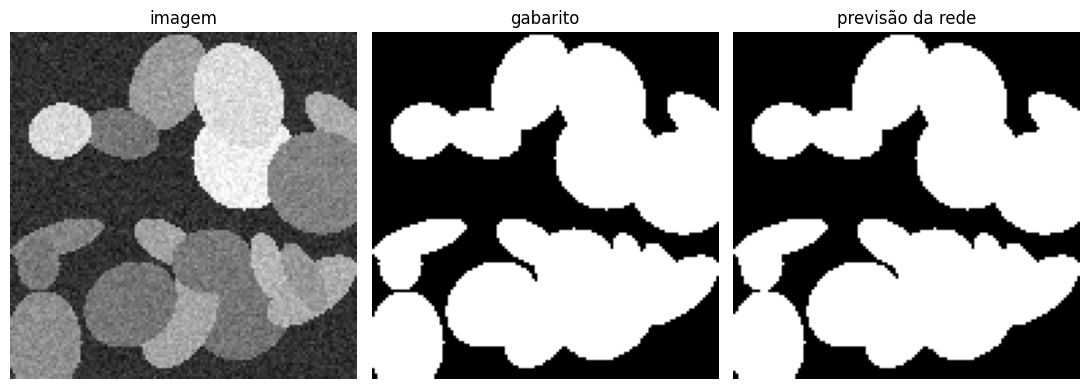

In [67]:
x, y = val_sint[0]
with torch.no_grad():
    prob = torch.sigmoid(modelo_sint(x.unsqueeze(0).to(device)))[0, 0].cpu().numpy()

fig, ax = plt.subplots(1, 3, figsize=(11, 4))
for a, imagem, titulo in zip(ax, [x[0], y[0], prob > 0.5], ["imagem", "gabarito", "previsão da rede"]):
    a.imshow(imagem, cmap="gray")
    a.set_title(titulo)
    a.axis("off")
plt.tight_layout()
plt.show()

## Dados reais — BBBC038 (DSB2018, `stage1_train`)

- **Instâncias**: os PNGs de `masks/` viram um mapa de instâncias no mesmo formato do gerador sintético (0 = fundo, k = k-ésimo núcleo).
- **Mesma entrada do sintético**: 1 canal em [0,1], núcleos claros sobre fundo escuro. Imagens de fundo claro (histologia H&E, campo claro) são invertidas; a decisão usa só a mediana da imagem, não a máscara, então vale também na inferência.
- **Modalidade** por heurística de cor e brilho do fundo: `fluorescencia` (cinza, fundo escuro), `histologia` (colorida), `campo_claro` (cinza, fundo claro).
- **Split treino/val/teste estratificado por modalidade** (70/15/15, seed fixa). Campo claro tem só ~18 imagens: sem estratificar, o teste poderia não ter nenhuma. A divisão é por imagem, antes de recortar, para que recortes da mesma imagem nunca caiam em splits diferentes.
- `DadosReais` tem a mesma interface de `DadosSinteticos` (recortes 128×128, `(x, y)` binário) e guarda o mapa de instâncias de cada recorte em `.instancias`.

In [68]:
RAIZ_DADOS = Path("data/BBBC038")
URL_TREINO = "https://data.broadinstitute.org/bbbc/BBBC038/stage1_train.zip"

def baixar_bbbc038(raiz=RAIZ_DADOS, url=URL_TREINO):
    pasta = raiz / "stage1_train"
    if pasta.exists() and any(pasta.iterdir()):
        return pasta

    raiz.mkdir(parents=True, exist_ok=True)
    arquivo_zip = raiz / "stage1_train.zip"
    if not arquivo_zip.exists():
        print("baixando", url)
        urllib.request.urlretrieve(url, arquivo_zip)

    with zipfile.ZipFile(arquivo_zip) as z:
        z.extractall(pasta)

    return pasta

In [69]:
def carregar_imagem_bbbc(pasta_imagem):
    """Devolve (rgb em [0,1], mapa de instâncias) de uma pasta <ImageId>/ do BBBC038."""
    arquivo = next((pasta_imagem / "images").glob("*.png"))
    rgb = np.asarray(Image.open(arquivo).convert("RGB")).astype(np.float32) / 255

    inst_mask = np.zeros(rgb.shape[:2], dtype=np.int32)
    for k, arquivo_mascara in enumerate(sorted((pasta_imagem / "masks").glob("*.png")), start=1):
        mascara = np.asarray(Image.open(arquivo_mascara).convert("L")) > 0
        inst_mask[mascara & (inst_mask == 0)] = k

    return rgb, inst_mask

def modalidade(rgb):
    """A mediana da imagem é o fundo (que domina a área); a saturação separa histologia das demais."""
    saturacao = (rgb.max(axis=2) - rgb.min(axis=2)).mean()
    fundo = np.median(rgb.mean(axis=2))

    if saturacao > 0.05:
        return "histologia"
    if fundo > 0.5:
        return "campo_claro"
    return "fluorescencia"

def para_cinza(rgb):
    """Cinza em [0,1] com núcleos claros sobre fundo escuro: inverte se o fundo (mediana) é claro
       e estica o contraste entre os percentis 1 e 99."""
    cinza = rgb.mean(axis=2)
    if np.median(cinza) > 0.5:
        cinza = 1 - cinza

    p1, p99 = np.percentile(cinza, [1, 99])
    if p99 - p1 > 1e-3:
        cinza = (cinza - p1) / (p99 - p1)

    return np.clip(cinza, 0, 1).astype(np.float32)

In [70]:
def carregar_bbbc038(pasta, cache=RAIZ_DADOS / "stage1_train_cache.pkl"):
    """Lista de dicts {id, imagem uint8 (já em cinza normalizado), inst int16, modalidade}.
       uint8/int16 mantêm o cache em ~300 MB; a leitura dos ~29 mil PNGs só acontece uma vez."""
    if cache.exists():
        return pickle.load(open(cache, "rb"))

    pastas = sorted(p for p in pasta.iterdir() if (p / "images").is_dir())
    itens = []

    for i, pasta_imagem in enumerate(pastas, start=1):
        rgb, inst_mask = carregar_imagem_bbbc(pasta_imagem)
        itens.append({"id": pasta_imagem.name,
                      "imagem": np.round(para_cinza(rgb) * 255).astype(np.uint8),
                      "inst": inst_mask.astype(np.int16),
                      "modalidade": modalidade(rgb)})
        if i % 100 == 0:
            print(f"  {i}/{len(pastas)} imagens lidas")

    pickle.dump(itens, open(cache, "wb"))
    return itens

itens_bbbc = carregar_bbbc038(baixar_bbbc038())

modalidades, contagens = np.unique([item["modalidade"] for item in itens_bbbc], return_counts=True)
print(f"{len(itens_bbbc)} imagens |", dict(zip(modalidades.tolist(), contagens.tolist())))

670 imagens | {'campo_claro': 18, 'fluorescencia': 546, 'histologia': 106}


In [71]:
def split_estratificado(itens, fracoes=(0.70, 0.15, 0.15), seed=0):
    """Embaralha e divide cada modalidade separadamente, na mesma proporção."""
    rng = np.random.default_rng(seed)
    por_modalidade = {}
    for i, item in enumerate(itens):
        por_modalidade.setdefault(item["modalidade"], []).append(i)

    treino, val, teste = [], [], []
    for indices in por_modalidade.values():
        indices = rng.permutation(indices)
        n_treino = round(fracoes[0] * len(indices))
        n_val = round(fracoes[1] * len(indices))
        treino += indices[:n_treino].tolist()
        val += indices[n_treino:n_treino + n_val].tolist()
        teste += indices[n_treino + n_val:].tolist()

    return treino, val, teste

idx_treino, idx_val, idx_teste = split_estratificado(itens_bbbc)

def contar(indices, modalidade):
    return sum(itens_bbbc[i]["modalidade"] == modalidade for i in indices)

print(f"{'modalidade':15s} | treino | val | teste")
for mod in modalidades:
    print(f"{mod:15s} | {contar(idx_treino, mod):6d} | {contar(idx_val, mod):3d} | {contar(idx_teste, mod):5d}")
print(f"{'total':15s} | {len(idx_treino):6d} | {len(idx_val):3d} | {len(idx_teste):5d}")

modalidade      | treino | val | teste
campo_claro     |     13 |   3 |     2
fluorescencia   |    382 |  82 |    82
histologia      |     74 |  16 |    16
total           |    469 | 101 |   100


In [72]:
def recorte_aleatorio(imagem, inst_mask, size, rng, tentativas=5):
    """Recorte size×size em posição aleatória; tenta algumas vezes até conter pelo menos um núcleo."""
    imagem = imagem.astype(np.float32) / 255
    inst_mask = inst_mask.astype(np.int32)
    altura, largura = imagem.shape

    for _ in range(tentativas):
        y0 = rng.integers(0, altura - size + 1)
        x0 = rng.integers(0, largura - size + 1)
        recorte_inst = inst_mask[y0:y0 + size, x0:x0 + size]
        if recorte_inst.any():
            break

    return imagem[y0:y0 + size, x0:x0 + size].copy(), recorte_inst.copy()

class DadosReais(Dataset):
    """Recortes 128×128 do BBBC038 com a mesma interface de DadosSinteticos.
       `.instancias[i]` e `.modalidades[i]` acompanham cada recorte; `.amostra(i)` devolve (imagem, inst_mask) em numpy."""
    def __init__(self, itens, indices, recortes_por_imagem, size=128, seed=0):
        rng = np.random.default_rng(seed)
        self.imagens, self.instancias, self.modalidades = [], [], []

        for i in indices:
            for _ in range(recortes_por_imagem):
                imagem, inst_mask = recorte_aleatorio(itens[i]["imagem"], itens[i]["inst"], size, rng)
                self.imagens.append(imagem)
                self.instancias.append(inst_mask)
                self.modalidades.append(itens[i]["modalidade"])

    def __len__(self):
        return len(self.imagens)

    def __getitem__(self, idx):
        x = torch.from_numpy(self.imagens[idx]).unsqueeze(0)
        y = torch.from_numpy((self.instancias[idx] > 0).astype(np.float32)).unsqueeze(0)
        return x, y

    def amostra(self, idx):
        return self.imagens[idx], self.instancias[idx]

treino_real = DadosReais(itens_bbbc, idx_treino, recortes_por_imagem=4, seed=1)
val_real = DadosReais(itens_bbbc, idx_val, recortes_por_imagem=2, seed=2)
teste_real = DadosReais(itens_bbbc, idx_teste, recortes_por_imagem=2, seed=3)
print(f"recortes 128×128 -> treino {len(treino_real)} | val {len(val_real)} | teste {len(teste_real)}")

recortes 128×128 -> treino 1876 | val 202 | teste 200


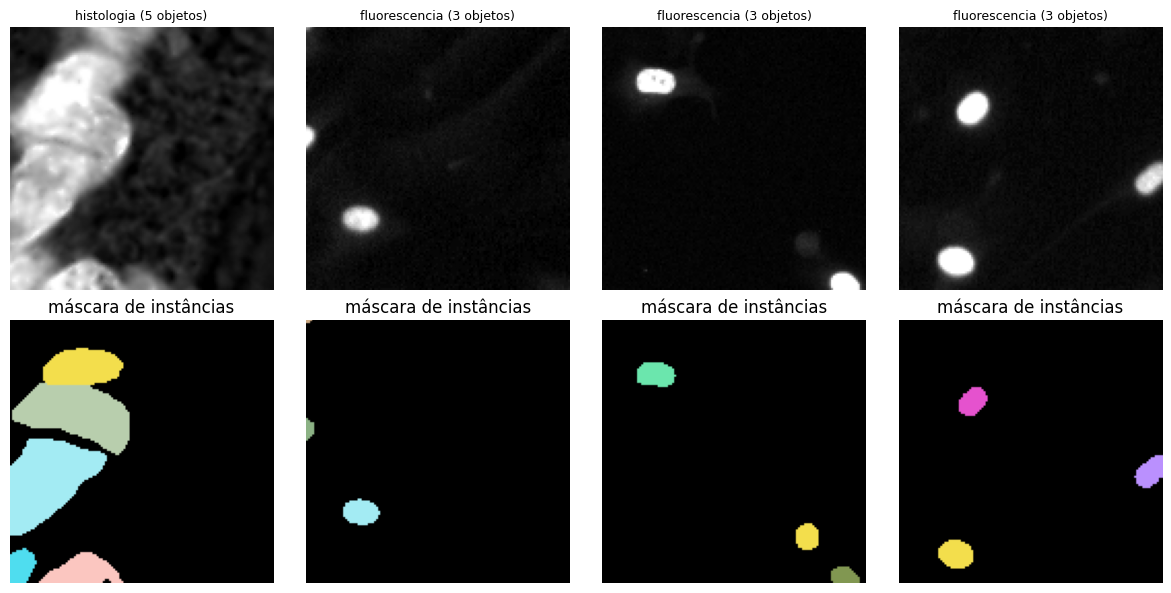

objetos por recorte: mín 0 | média 7.9 | máx 45


In [73]:
rng = np.random.default_rng(0)
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for col in range(4):
    k = rng.integers(len(treino_real))
    imagem, inst_mask = treino_real.amostra(k)
    axes[0, col].imshow(imagem, cmap="gray", vmin=0, vmax=1)
    axes[0, col].set_title(f"{treino_real.modalidades[k]} ({n_objetos(inst_mask)} objetos)", fontsize=9)
    axes[1, col].imshow(colorir_instancias(inst_mask))
    axes[1, col].set_title("máscara de instâncias")

for ax in axes.ravel():
    ax.axis("off")
plt.tight_layout()
plt.show()

contagens = np.array([n_objetos(inst_mask) for inst_mask in treino_real.instancias])
print(f"objetos por recorte: mín {contagens.min()} | média {contagens.mean():.1f} | máx {contagens.max()}")

## Parte 1 — Baseline de segmentação semântica

Mesmo pipeline da Parte 0, agora no BBBC038, seguindo os cinco itens do enunciado:

1. U-Net binária (fundo vs. núcleo), reportando **IoU e Dice**;
2. instâncias pelo método **ingênuo** (limiar + componentes conexos);
3. avaliação **como instâncias**: mAP em IoU de 0,50 a 0,95 e **erro absoluto de contagem**;
4. **regra de matching** documentada;
5. mAP e erro de contagem em função da **densidade** de objetos.

O treino ajusta os pesos, a validação escolhe a época e todos os números reportados são do teste.

### 1.1 U-Net binária

Mesma `UNetPequena`, BCE e Adam da Parte 0. Duas diferenças: flips horizontais/verticais como augmentation (núcleos não têm orientação preferida) e mais épocas, porque os dados reais são bem mais variados. Os pesos usados daqui em diante são os da melhor época na validação.

In [74]:
def flip_aleatorio(x, y, rng):
    """O mesmo flip (horizontal e/ou vertical) na imagem e na máscara."""
    if rng.random() < 0.5:
        x, y = x.flip(-1), y.flip(-1)
    if rng.random() < 0.5:
        x, y = x.flip(-2), y.flip(-2)
    return x, y

modelo_real = UNetPequena().to(device)

inicio = time.time()
historico_real = treinar(modelo_real, treino_real, val_real, epocas=20, criterio=nn.BCEWithLogitsLoss(),
                         metricas=metricas_binarias, augmentar=flip_aleatorio)
print(f"treinou em {time.time() - inicio:.1f}s")

época  1 | perda 0.397 | val_dice 0.796 | val_iou 0.687
época  2 | perda 0.167 | val_dice 0.857 | val_iou 0.775
época  3 | perda 0.115 | val_dice 0.877 | val_iou 0.805
época  4 | perda 0.100 | val_dice 0.871 | val_iou 0.797
época  5 | perda 0.094 | val_dice 0.875 | val_iou 0.802
época  6 | perda 0.090 | val_dice 0.873 | val_iou 0.799
época  7 | perda 0.085 | val_dice 0.881 | val_iou 0.810
época  8 | perda 0.087 | val_dice 0.877 | val_iou 0.804
época  9 | perda 0.082 | val_dice 0.882 | val_iou 0.813
época 10 | perda 0.080 | val_dice 0.874 | val_iou 0.802
época 11 | perda 0.081 | val_dice 0.878 | val_iou 0.808
época 12 | perda 0.078 | val_dice 0.881 | val_iou 0.813
época 13 | perda 0.077 | val_dice 0.882 | val_iou 0.814
época 14 | perda 0.076 | val_dice 0.877 | val_iou 0.811
época 15 | perda 0.075 | val_dice 0.880 | val_iou 0.813
época 16 | perda 0.077 | val_dice 0.882 | val_iou 0.814
época 17 | perda 0.073 | val_dice 0.876 | val_iou 0.805
época 18 | perda 0.072 | val_dice 0.885 | val_io

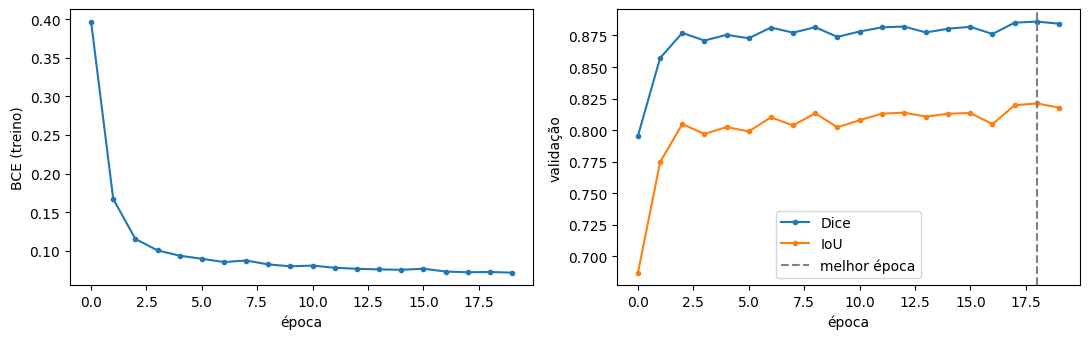

In [75]:
melhor_epoca = int(np.argmax(historico_real["val_dice"]))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].plot(historico_real["perda"], "-o", ms=3)
ax[0].set_xlabel("época")
ax[0].set_ylabel("BCE (treino)")
ax[1].plot(historico_real["val_dice"], "-o", ms=3, label="Dice")
ax[1].plot(historico_real["val_iou"], "-o", ms=3, label="IoU")
ax[1].axvline(melhor_epoca, ls="--", color="gray", label="melhor época")
ax[1].set_xlabel("época")
ax[1].set_ylabel("validação")
ax[1].legend()
plt.tight_layout()
plt.show()

**Métrica semântica no teste.** Dice e IoU médios por recorte, no total e por modalidade. A quebra por modalidade é o motivo do split estratificado: a média global esconderia um resultado ruim em campo claro, que tem só 2 imagens no teste.

In [76]:
dice_teste, iou_teste = avaliar_binario(modelo_real, teste_real)
modalidades_teste = np.array(teste_real.modalidades)

print("=== Segmentação binária no teste (BBBC038) ===")
print(f"{'modalidade':15s} | n   | Dice  | IoU")
for mod in modalidades:
    sel = modalidades_teste == mod
    print(f"{mod:15s} | {sel.sum():3d} | {dice_teste[sel].mean():.3f} | {iou_teste[sel].mean():.3f}")
print(f"{'total':15s} | {len(teste_real):3d} | {dice_teste.mean():.3f} | {iou_teste.mean():.3f}")

Path("checkpoints").mkdir(exist_ok=True)
torch.save(modelo_real.state_dict(), "checkpoints/unet_binaria_bbbc038.pt")

=== Segmentação binária no teste (BBBC038) ===
modalidade      | n   | Dice  | IoU
campo_claro     |   4 | 0.448 | 0.326
fluorescencia   | 164 | 0.897 | 0.834
histologia      |  32 | 0.851 | 0.759
total           | 200 | 0.880 | 0.812


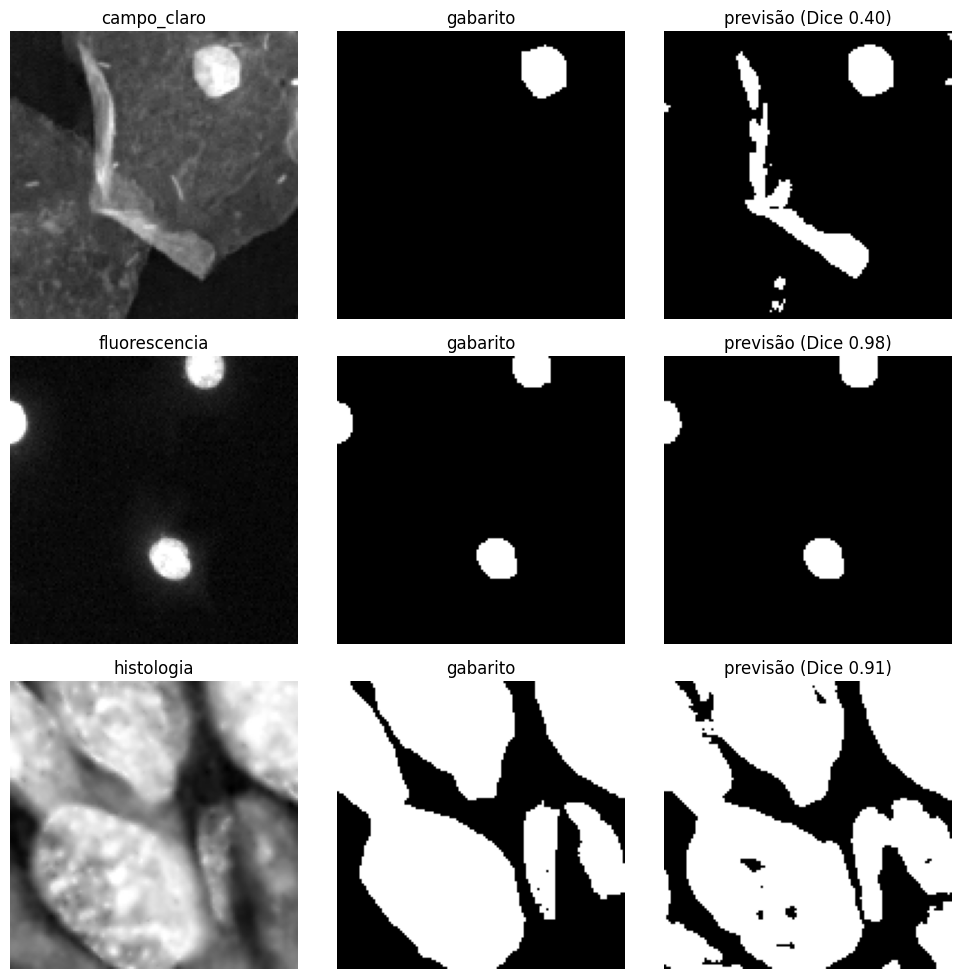

In [77]:
exemplos = [int(np.argmax(modalidades_teste == mod)) for mod in modalidades]

fig, axes = plt.subplots(len(exemplos), 3, figsize=(10, 3.3 * len(exemplos)))
for ax, k in zip(axes, exemplos):
    x, y = teste_real[k]
    with torch.no_grad():
        prob = torch.sigmoid(modelo_real(x.unsqueeze(0).to(device)))[0, 0].cpu().numpy()

    ax[0].imshow(x[0], cmap="gray", vmin=0, vmax=1)
    ax[0].set_title(modalidades_teste[k])
    ax[1].imshow(y[0], cmap="gray")
    ax[1].set_title("gabarito")
    ax[2].imshow(prob > 0.5, cmap="gray")
    ax[2].set_title(f"previsão (Dice {dice_teste[k]:.2f})")

for ax in axes.ravel():
    ax.axis("off")
plt.tight_layout()
plt.show()

### 1.2 Instâncias pelo método ingênuo

Binariza a probabilidade em 0,5 e chama de objeto cada componente conexo (`ndimage.label`, conectividade 4). Dois núcleos encostados viram uma mancha só — e no BBBC038 núcleos encostados são a regra.

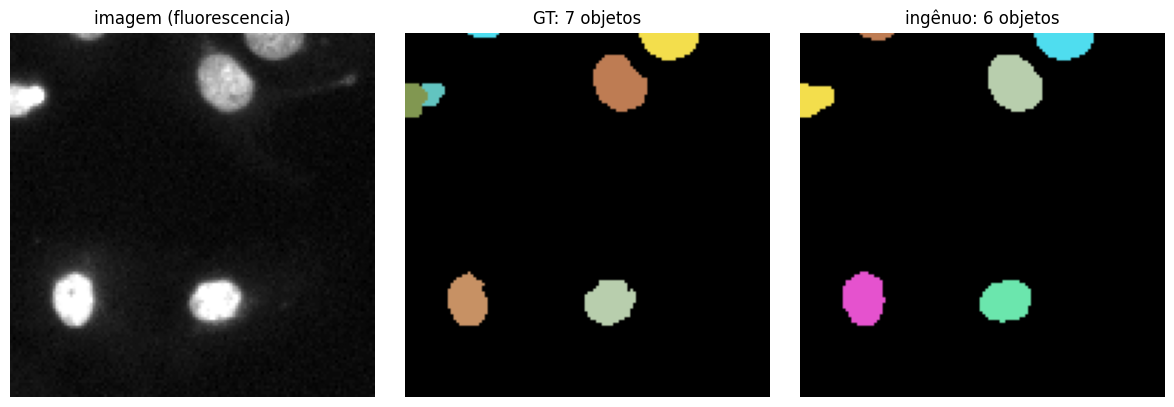

In [78]:
def instancias_ingenuas(prob, limiar=0.5):
    rotulos, _ = ndimage.label(prob > limiar)
    return rotulos.astype(np.int32)

def prever_prob(modelo, imagem):
    modelo.eval()
    x = torch.from_numpy(imagem)[None, None].to(device)
    with torch.no_grad():
        return torch.sigmoid(modelo(x))[0, 0].cpu().numpy()

def segmentar_ingenuo(imagem):
    return instancias_ingenuas(prever_prob(modelo_real, imagem))

k = 7
imagem, gt_labels = teste_real.amostra(k)
pred_labels = segmentar_ingenuo(imagem)

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(imagem, cmap="gray", vmin=0, vmax=1)
ax[0].set_title(f"imagem ({teste_real.modalidades[k]})")
ax[1].imshow(colorir_instancias(gt_labels))
ax[1].set_title(f"GT: {n_objetos(gt_labels)} objetos")
ax[2].imshow(colorir_instancias(pred_labels))
ax[2].set_title(f"ingênuo: {n_objetos(pred_labels)} objetos")
for a in ax:
    a.axis("off")
plt.tight_layout()
plt.show()

### 1.3 – 1.4 Avaliação como instâncias e regra de matching

O AP do slide 6 é por classe (métrica semântica). Aqui o matching é feito à mão, no nível de instância:

1. **Matriz de IoU** entre cada objeto previsto e cada objeto verdadeiro (só pares que se tocam têm IoU > 0).
2. **Matching guloso por IoU decrescente**: para um limiar $t$, os pares com IoU $\ge t$ são percorridos do maior para o menor IoU e cada objeto (previsto ou verdadeiro) entra em no máximo um par. Pares casados são TP; previstos que sobraram, FP; verdadeiros sem par, FN. Escolhemos o guloso, e não o Hungarian, porque é o que a métrica oficial do DSB2018 usa e porque com IoU $\ge 0{,}5$ um objeto previsto raramente tem mais de um candidato — na prática os dois coincidem.
3. $\mathrm{AP}_t = TP / (TP + FP + FN)$, a definição do DSB2018.
4. **mAP** = média de $\mathrm{AP}_t$ em $t \in \{0{,}50, 0{,}55, \dots, 0{,}95\}$, por imagem, depois média sobre as imagens.
5. **Erro absoluto de contagem** = $|\#\text{previstos} - \#\text{verdadeiros}|$ por imagem.

Núcleos fundidos pelo ingênuo contam uma vez como TP (se o IoU com o maior deles passar do limiar) e os demais viram FN — é assim que o fracasso da baseline aparece no número.

In [79]:
LIMIARES_IOU = np.arange(0.5, 1.0, 0.05)

def matriz_iou(pred_labels, gt_labels):
    """IoU[i, j] entre o i-ésimo objeto previsto e o j-ésimo verdadeiro."""
    ids_pred = np.unique(pred_labels[pred_labels != 0])
    ids_gt = np.unique(gt_labels[gt_labels != 0])
    iou = np.zeros((len(ids_pred), len(ids_gt)), dtype=np.float32)
    coluna = {j: c for c, j in enumerate(ids_gt)}

    for linha, i in enumerate(ids_pred):
        objeto = pred_labels == i
        vizinhos = np.unique(gt_labels[objeto])
        for j in vizinhos[vizinhos != 0]:
            intersecao = np.logical_and(objeto, gt_labels == j).sum()
            uniao = objeto.sum() + (gt_labels == j).sum() - intersecao
            iou[linha, coluna[j]] = intersecao / uniao

    return iou

def matching_guloso(iou, limiar):
    """Casa os pares de maior IoU primeiro, cada objeto no máximo uma vez. Devolve (TP, FP, FN)."""
    n_pred, n_gt = iou.shape
    pares = sorted(((iou[i, j], i, j) for i in range(n_pred) for j in range(n_gt) if iou[i, j] >= limiar), reverse=True)
    usados_pred, usados_gt = set(), set()

    for _, i, j in pares:
        if i not in usados_pred and j not in usados_gt:
            usados_pred.add(i)
            usados_gt.add(j)

    tp = len(usados_pred)
    return tp, n_pred - tp, n_gt - tp

def aps_de_uma_imagem(pred_labels, gt_labels):
    """AP em cada limiar de IoU para um par (previsão, gabarito)."""
    iou = matriz_iou(pred_labels, gt_labels)
    aps = []
    for limiar in LIMIARES_IOU:
        tp, fp, fn = matching_guloso(iou, limiar)
        aps.append(tp / (tp + fp + fn) if tp + fp + fn > 0 else 0.0)
    return np.array(aps)

In [80]:
def avaliar_instancias(segmentar, dados):
    """mAP, erro de contagem e densidade por recorte. `segmentar(imagem) -> labels` é rede + pós-processamento."""
    resultado = {"aps": [], "densidades": [], "erros": []}

    for k in range(len(dados)):
        imagem, gt_labels = dados.amostra(k)
        pred_labels = segmentar(imagem)
        resultado["aps"].append(aps_de_uma_imagem(pred_labels, gt_labels))
        resultado["densidades"].append(n_objetos(gt_labels))
        resultado["erros"].append(abs(n_objetos(pred_labels) - n_objetos(gt_labels)))

    resultado = {chave: np.array(valor) for chave, valor in resultado.items()}
    resultado["maps"] = resultado["aps"].mean(axis=1)
    resultado["mAP"] = resultado["maps"].mean()
    resultado["erro_contagem_medio"] = resultado["erros"].mean()
    resultado["modalidades"] = np.array(dados.modalidades)
    return resultado

res_ingenuo = avaliar_instancias(segmentar_ingenuo, teste_real)

print("=== Baseline ingênua como instâncias (teste, BBBC038) ===")
print(f"mAP (IoU 0.50 a 0.95): {res_ingenuo['mAP']:.3f}")
print(f"erro absoluto de contagem por recorte: {res_ingenuo['erro_contagem_medio']:.2f}\n")

print("AP por limiar de IoU:")
for limiar, ap in zip(LIMIARES_IOU, res_ingenuo["aps"].mean(axis=0)):
    print(f"  IoU >= {limiar:.2f}: {ap:.3f}")

print(f"\n{'modalidade':15s} | n   | mAP   | erro de contagem")
for mod in modalidades:
    sel = res_ingenuo["modalidades"] == mod
    print(f"{mod:15s} | {sel.sum():3d} | {res_ingenuo['maps'][sel].mean():.3f} | {res_ingenuo['erros'][sel].mean():.2f}")

=== Baseline ingênua como instâncias (teste, BBBC038) ===
mAP (IoU 0.50 a 0.95): 0.488
erro absoluto de contagem por recorte: 2.20

AP por limiar de IoU:
  IoU >= 0.50: 0.685
  IoU >= 0.55: 0.648
  IoU >= 0.60: 0.620
  IoU >= 0.65: 0.588
  IoU >= 0.70: 0.550
  IoU >= 0.75: 0.500
  IoU >= 0.80: 0.468
  IoU >= 0.85: 0.392
  IoU >= 0.90: 0.283
  IoU >= 0.95: 0.146

modalidade      | n   | mAP   | erro de contagem
campo_claro     |   4 | 0.098 | 8.00
fluorescencia   | 164 | 0.540 | 1.66
histologia      |  32 | 0.268 | 4.22


### 1.5 Quantificando o fracasso: métricas em função da densidade

Densidade = número de núcleos verdadeiros no recorte. A distribuição é assimétrica (muitos recortes com poucos núcleos, alguns com dezenas), então as faixas são quantis, para que cada ponto da curva média tenha o mesmo número de recortes. Quanto mais núcleos, mais eles se encostam e mais o ingênuo funde objetos: o mAP deve cair e o erro de contagem crescer.

ingênuo    | Spearman(densidade, mAP) = -0.267 | Spearman(densidade, erro) = +0.516


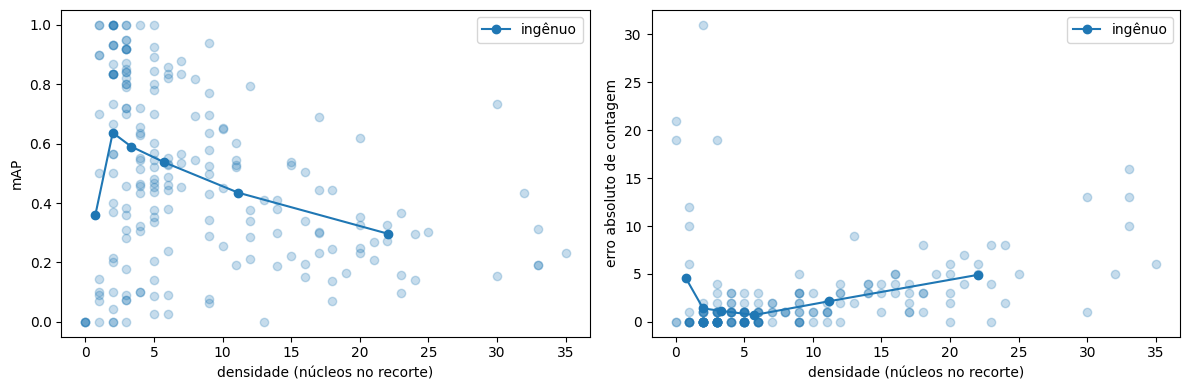

In [81]:
def plotar_por_densidade(resultados):
    """mAP e erro de contagem de cada recorte contra a densidade, com a média por faixa de quantis; uma curva por método."""
    densidades = next(iter(resultados.values()))["densidades"]
    bordas = np.unique(np.quantile(densidades, np.linspace(0, 1, 7)))
    faixa = np.clip(np.digitize(densidades, bordas) - 1, 0, len(bordas) - 2)
    faixas = [faixa == f for f in range(len(bordas) - 1) if (faixa == f).any()]
    centros = [densidades[sel].mean() for sel in faixas]
    cores = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    for cor, (nome, res) in zip(cores, resultados.items()):
        for a, chave in zip(ax, ["maps", "erros"]):
            a.scatter(densidades, res[chave], color=cor, alpha=0.25)
            a.plot(centros, [res[chave][sel].mean() for sel in faixas], "-o", color=cor, label=nome)
        print(f"{nome:10s} | Spearman(densidade, mAP) = {spearmanr(densidades, res['maps']).statistic:+.3f}"
              f" | Spearman(densidade, erro) = {spearmanr(densidades, res['erros']).statistic:+.3f}")

    ax[0].set_ylabel("mAP")
    ax[1].set_ylabel("erro absoluto de contagem")
    for a in ax:
        a.set_xlabel("densidade (núcleos no recorte)")
        a.legend()
    plt.tight_layout()
    plt.show()

plotar_por_densidade({"ingênuo": res_ingenuo})

**O que a Parte 1 mostra.** A segmentação semântica funciona: a rede sabe onde há núcleo. O problema está só na decodificação em instâncias — o ingênuo funde núcleos encostados, o AP despenca nos limiares altos de IoU e o erro de contagem cresce com a densidade. É isso que a cabeça de instâncias da Parte 2 precisa resolver, com o mesmo encoder-decoder e as mesmas métricas: `avaliar_instancias` recebe qualquer `segmentar(imagem) -> labels`, então a comparação é direta.

## Parte 2 — Cabeça de instâncias: Trilha A (fronteiras + watershed)

Na Parte 1 a rede acerta *onde* há núcleo, mas "núcleo" é a mesma classe dos dois lados de um contato, então limiar + componentes conexos funde vizinhos. O encoder-decoder fica o mesmo; muda **o que ele prevê**: três classes, fundo / interior / fronteira. Interiores de núcleos vizinhos nunca se tocam por construção, então cada componente conexo de interior é um marcador, e o watershed cresce os marcadores sobre o foreground.

As três decisões pedidas no enunciado — como gerar o rótulo e com que espessura, como pesar a classe fronteira, como decodificar — estão em 2.1 a 2.3; 2.4 compara com a baseline nas mesmas métricas.

### 2.1 Representação: rótulo de 3 classes a partir das máscaras individuais

Cada máscara individual é erodida em `espessura` pixels: o que sobra é **interior** (1), o anel removido é **fronteira** (2). O anel envolve o núcleo inteiro, não só o trecho em contato com outro núcleo — é mais simples, dá mais pixels à classe minoritária, e o que importa para o watershed (interiores de vizinhos separados) vale do mesmo jeito.

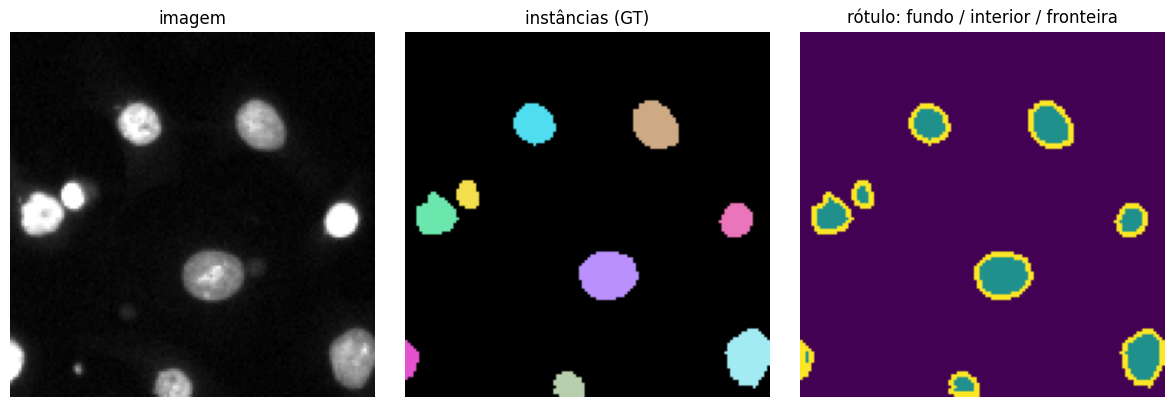

In [82]:
def rotulo_3classes(inst_mask, espessura):
    classes = np.zeros(inst_mask.shape, dtype=np.int64)
    for k in ids_objetos(inst_mask):
        nucleo = inst_mask == k
        classes[nucleo] = 2
        classes[ndimage.binary_erosion(nucleo, iterations=espessura)] = 1
    return classes

imagem, inst_mask = treino_real.amostra(0)

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(imagem, cmap="gray", vmin=0, vmax=1)
ax[0].set_title("imagem")
ax[1].imshow(colorir_instancias(inst_mask))
ax[1].set_title("instâncias (GT)")
ax[2].imshow(rotulo_3classes(inst_mask, espessura=2), cmap="viridis", vmin=0, vmax=2)
ax[2].set_title("rótulo: fundo / interior / fronteira")
for a in ax:
    a.axis("off")
plt.tight_layout()
plt.show()

### 2.2 Decodificação por watershed

Marcadores = componentes conexos do interior previsto; máscara = interior ∪ fronteira; relevo = −distância ao fundo. Cada pixel de fronteira vai para a bacia do marcador mais próximo.

A mesma decodificação aplicada ao **rótulo verdadeiro** dá o teto da representação: o mAP que uma rede perfeita alcançaria. O teto mede só o custo do anel — quanto mais grosso, mais pixels o watershed precisa reatribuir e mais núcleos pequenos perdem o interior (ficam sem marcador e desaparecem). O benefício de um anel mais grosso, ser mais fácil de prever e separar vizinhos mesmo com erro da rede, só aparece treinando. Ficamos com 2 px como compromisso; a espessura é um eixo natural de ablação para a Parte 3.

In [83]:
def decodificar_watershed(classes):
    interior = classes == 1
    foreground = classes >= 1
    marcadores, _ = ndimage.label(interior)
    relevo = -ndimage.distance_transform_edt(foreground)
    return watershed(relevo, markers=marcadores, mask=foreground).astype(np.int32)

print("espessura | mAP teto (val) | núcleos sem marcador")
for espessura in (1, 2, 3):
    maps, sem_marcador, total = [], 0, 0
    for inst_mask in val_real.instancias:
        classes = rotulo_3classes(inst_mask, espessura)
        maps.append(aps_de_uma_imagem(decodificar_watershed(classes), inst_mask).mean())
        ids = ids_objetos(inst_mask)
        total += len(ids)
        sem_marcador += sum(not (classes[inst_mask == k] == 1).any() for k in ids)
    print(f"{espessura:9d} | {np.mean(maps):14.3f} | {sem_marcador / total:.1%}")

ESPESSURA = 2

espessura | mAP teto (val) | núcleos sem marcador
        1 |          0.922 | 5.7%
        2 |          0.844 | 11.2%
        3 |          0.752 | 19.8%


### 2.3 Rede e perda

A mesma `UNetPequena`, com 3 canais de saída. A fronteira é uma fração pequena dos pixels, então a perda é CE balanceada com **pesos por frequência mediana** (Eigen & Fergus, 2015 — o esquema da SegNet): $w_c = \mathrm{mediana}(f) / f_c$, com $f_c$ a fração de pixels da classe $c$ no treino. A época é escolhida pelo **mAP na validação depois do watershed**, que é a métrica que interessa, e não pela perda por pixel.

In [84]:
class DadosTresClasses(Dataset):
    """Os mesmos recortes de um DadosReais, com o rótulo de 3 classes como alvo (tensor (128, 128) de inteiros)."""
    def __init__(self, dados, espessura):
        self.imagens = dados.imagens
        self.classes = [rotulo_3classes(inst_mask, espessura) for inst_mask in dados.instancias]

    def __len__(self):
        return len(self.imagens)

    def __getitem__(self, idx):
        return torch.from_numpy(self.imagens[idx]).unsqueeze(0), torch.from_numpy(self.classes[idx])

treino_3c = DadosTresClasses(treino_real, ESPESSURA)

frequencia = np.bincount(np.concatenate([classes.ravel() for classes in treino_3c.classes]), minlength=3)
frequencia = frequencia / frequencia.sum()
pesos_classe = torch.tensor(np.median(frequencia) / frequencia, dtype=torch.float32, device=device)
print("fração de pixels (fundo, interior, fronteira):", np.round(frequencia, 4))
print("pesos da CE balanceada:", np.round(pesos_classe.cpu().numpy(), 2))

fração de pixels (fundo, interior, fronteira): [0.8558 0.0982 0.046 ]
pesos da CE balanceada: [0.11 1.   2.13]


In [85]:
def prever_classes(modelo, imagem):
    modelo.eval()
    x = torch.from_numpy(imagem)[None, None].to(device)
    with torch.no_grad():
        return modelo(x).argmax(dim=1)[0].cpu().numpy()

def metrica_watershed(modelo, val):
    segmentar = lambda imagem: decodificar_watershed(prever_classes(modelo, imagem))
    return {"val_mAP": avaliar_instancias(segmentar, val)["mAP"]}

modelo_3c = UNetPequena(n_saidas=3).to(device)

inicio = time.time()
historico_3c = treinar(modelo_3c, treino_3c, val_real, epocas=20, criterio=nn.CrossEntropyLoss(weight=pesos_classe),
                       metricas=metrica_watershed, augmentar=flip_aleatorio)
print(f"treinou em {time.time() - inicio:.1f}s")

torch.save(modelo_3c.state_dict(), "checkpoints/unet_3classes_bbbc038.pt")

def segmentar_watershed(imagem):
    return decodificar_watershed(prever_classes(modelo_3c, imagem))

época  1 | perda 0.463 | val_mAP 0.300
época  2 | perda 0.352 | val_mAP 0.304
época  3 | perda 0.333 | val_mAP 0.260
época  4 | perda 0.318 | val_mAP 0.282
época  5 | perda 0.313 | val_mAP 0.162
época  6 | perda 0.301 | val_mAP 0.259
época  7 | perda 0.299 | val_mAP 0.336
época  8 | perda 0.292 | val_mAP 0.385
época  9 | perda 0.295 | val_mAP 0.294
época 10 | perda 0.283 | val_mAP 0.304
época 11 | perda 0.284 | val_mAP 0.373
época 12 | perda 0.280 | val_mAP 0.350
época 13 | perda 0.278 | val_mAP 0.282
época 14 | perda 0.272 | val_mAP 0.355
época 15 | perda 0.269 | val_mAP 0.316
época 16 | perda 0.268 | val_mAP 0.363
época 17 | perda 0.269 | val_mAP 0.332
época 18 | perda 0.267 | val_mAP 0.390
época 19 | perda 0.263 | val_mAP 0.357
época 20 | perda 0.267 | val_mAP 0.377
treinou em 177.8s


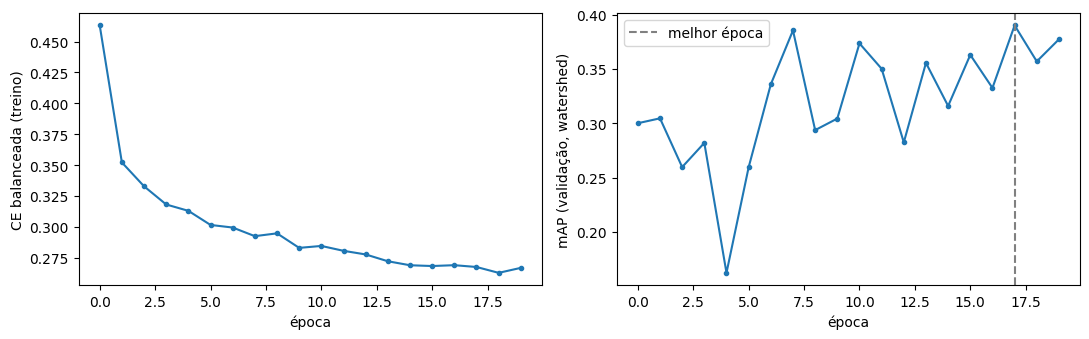

In [86]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].plot(historico_3c["perda"], "-o", ms=3)
ax[0].set_xlabel("época")
ax[0].set_ylabel("CE balanceada (treino)")
ax[1].plot(historico_3c["val_mAP"], "-o", ms=3)
ax[1].axvline(int(np.argmax(historico_3c["val_mAP"])), ls="--", color="gray", label="melhor época")
ax[1].set_xlabel("época")
ax[1].set_ylabel("mAP (validação, watershed)")
ax[1].legend()
plt.tight_layout()
plt.show()

### 2.4 Métricas lado a lado com a baseline

Mesmo conjunto de teste, mesmo `avaliar_instancias`, mesma regra de matching; só muda o `segmentar`.

In [87]:
res_watershed = avaliar_instancias(segmentar_watershed, teste_real)
resultados = {"ingênuo": res_ingenuo, "watershed": res_watershed}

print(f"{'método':10s} | mAP   | erro de contagem")
for nome, res in resultados.items():
    print(f"{nome:10s} | {res['mAP']:.3f} | {res['erro_contagem_medio']:.2f}")

print(f"\n{'IoU >=':6s} | " + " | ".join(f"{nome:9s}" for nome in resultados))
for i, limiar in enumerate(LIMIARES_IOU):
    print(f"{limiar:6.2f} | " + " | ".join(f"{res['aps'][:, i].mean():9.3f}" for res in resultados.values()))

print(f"\n{'modalidade':15s} | " + " | ".join(f"mAP {nome:9s}" for nome in resultados))
for mod in modalidades:
    sel = res_watershed["modalidades"] == mod
    print(f"{mod:15s} | " + " | ".join(f"{res['maps'][sel].mean():13.3f}" for res in resultados.values()))

método     | mAP   | erro de contagem
ingênuo    | 0.488 | 2.20
watershed  | 0.370 | 2.28

IoU >= | ingênuo   | watershed
  0.50 |     0.685 |     0.627
  0.55 |     0.648 |     0.594
  0.60 |     0.620 |     0.556
  0.65 |     0.588 |     0.526
  0.70 |     0.550 |     0.471
  0.75 |     0.500 |     0.398
  0.80 |     0.468 |     0.279
  0.85 |     0.392 |     0.176
  0.90 |     0.283 |     0.069
  0.95 |     0.146 |     0.007

modalidade      | mAP ingênuo   | mAP watershed
campo_claro     |         0.098 |         0.064
fluorescencia   |         0.540 |         0.406
histologia      |         0.268 |         0.225


ingênuo    | Spearman(densidade, mAP) = -0.267 | Spearman(densidade, erro) = +0.516
watershed  | Spearman(densidade, mAP) = -0.160 | Spearman(densidade, erro) = +0.420


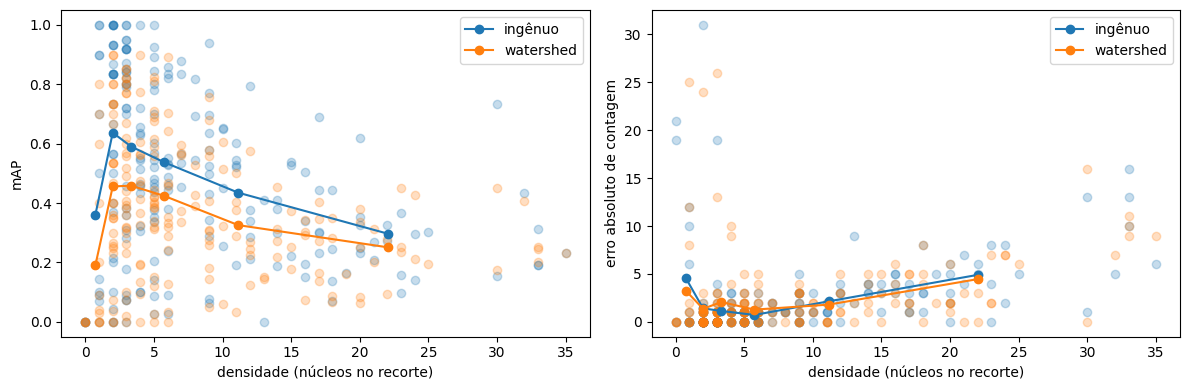

In [88]:
plotar_por_densidade(resultados)

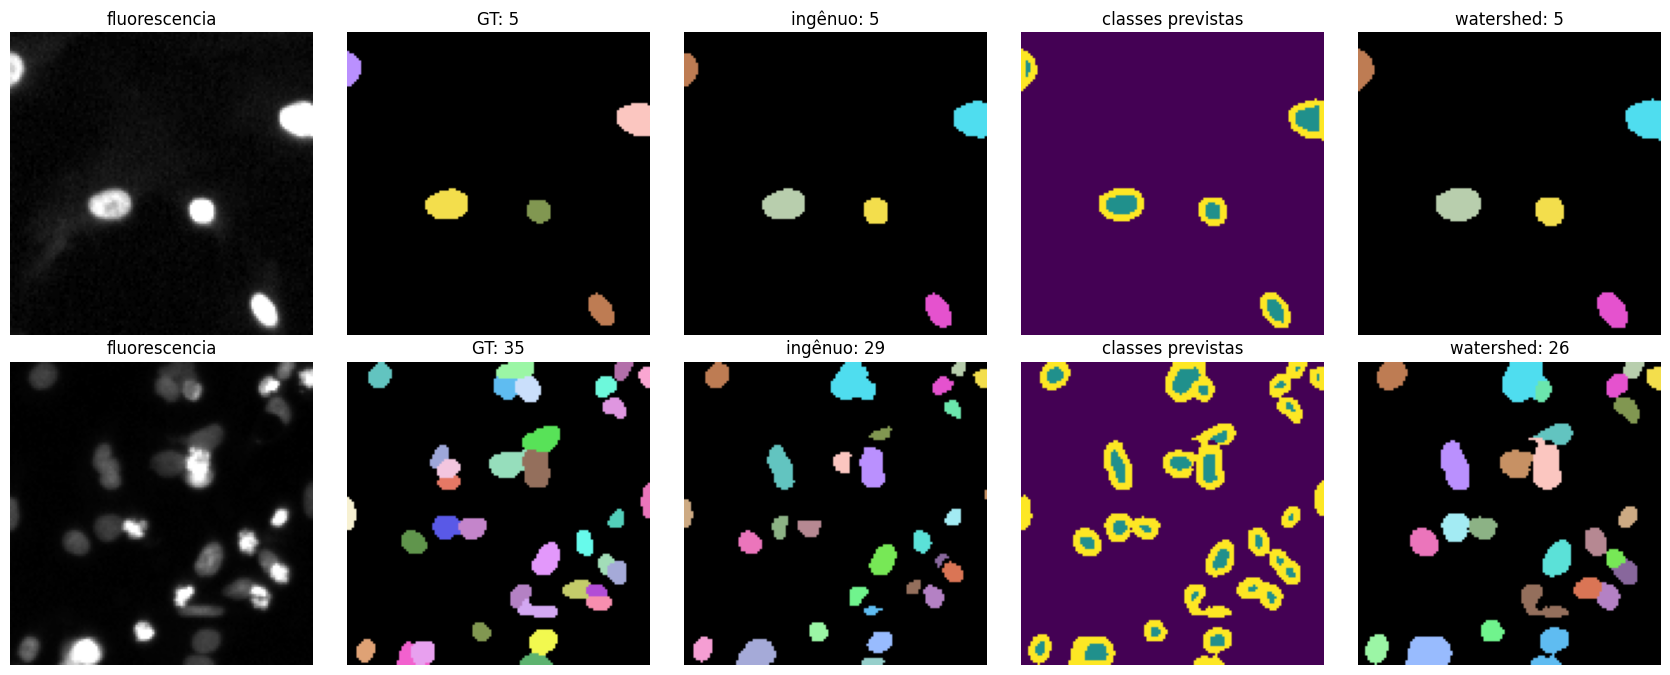

In [89]:
ordem = np.argsort(res_watershed["densidades"])
exemplos = [int(ordem[len(ordem) // 2]), int(ordem[-1])]

fig, axes = plt.subplots(len(exemplos), 5, figsize=(17, 3.4 * len(exemplos)))
for ax, k in zip(axes, exemplos):
    imagem, gt_labels = teste_real.amostra(k)
    ingenuo = segmentar_ingenuo(imagem)
    classes = prever_classes(modelo_3c, imagem)
    ws = decodificar_watershed(classes)

    ax[0].imshow(imagem, cmap="gray", vmin=0, vmax=1)
    ax[0].set_title(teste_real.modalidades[k])
    ax[1].imshow(colorir_instancias(gt_labels))
    ax[1].set_title(f"GT: {n_objetos(gt_labels)}")
    ax[2].imshow(colorir_instancias(ingenuo))
    ax[2].set_title(f"ingênuo: {n_objetos(ingenuo)}")
    ax[3].imshow(classes, cmap="viridis", vmin=0, vmax=2)
    ax[3].set_title("classes previstas")
    ax[4].imshow(colorir_instancias(ws))
    ax[4].set_title(f"watershed: {n_objetos(ws)}")

for ax in axes.ravel():
    ax.axis("off")
plt.tight_layout()
plt.show()

**Por que resolve o problema da Parte 1.** O ingênuo falha porque a representação binária não tem como codificar "aqui termina um núcleo e começa outro". A classe fronteira codifica exatamente isso, e o watershed a partir dos interiores transforma essa informação em instâncias separadas. O ganho deve aparecer onde a baseline mais perde: nos limiares altos de IoU e nos recortes densos. O teto de 2.2 separa o que ainda é perdido pela própria representação (fronteira reatribuída pelo watershed) do que é erro da rede.

## Parte 3 — Ablações

Dois eixos, cada configuração treinada com **2 seeds**, reportando **média ± desvio do mAP no teste** (watershed). Tudo o que não é o fator ablacionado fica fixo: os recortes e o rótulo de 3 classes da Parte 2, os flips, Adam com lr = 1e-3, a época escolhida pelo mAP na validação. As ablações usam 12 épocas em vez de 20 para caber no tempo; a comparação é relativa, não com o modelo final.

`ablacao` treina e guarda os modelos; as métricas são calculadas depois, para que o mesmo conjunto de modelos possa ser lido por mais de uma métrica (no Eixo 2 isso importa).

In [90]:
teste_3c = DadosTresClasses(teste_real, ESPESSURA)

def ablacao(configs, seeds=(0, 1), epocas=12):
    """Treina cada configuração {nome: (criar_modelo, criterio)} uma vez por seed e devolve {nome: [modelos]}."""
    modelos = {}
    for nome, (criar_modelo, criterio) in configs.items():
        modelos[nome] = []
        for seed in seeds:
            torch.manual_seed(seed)
            modelo = criar_modelo().to(device)
            historico = treinar(modelo, treino_3c, val_real, epocas, criterio, metrica_watershed,
                                augmentar=flip_aleatorio, seed=seed, verboso=False)
            modelos[nome].append(modelo)
            print(f"{nome:22s} | seed {seed} | melhor val mAP {max(historico['val_mAP']):.3f}")
    return modelos

def map_teste(modelo):
    segmentar = lambda imagem: decodificar_watershed(prever_classes(modelo, imagem))
    return avaliar_instancias(segmentar, teste_real)["mAP"]

def recall_fronteira(modelo):
    """Fração dos pixels de fronteira do gabarito que a rede classifica como fronteira."""
    acertos, total = 0, 0
    for imagem, classes in zip(teste_3c.imagens, teste_3c.classes):
        fronteira = classes == 2
        acertos += (prever_classes(modelo, imagem)[fronteira] == 2).sum()
        total += fronteira.sum()
    return acertos / total

def resumo(modelos, metrica):
    """{nome: array com a métrica de cada seed}"""
    return {nome: np.array([metrica(modelo) for modelo in lista]) for nome, lista in modelos.items()}

def plotar_ablacao(valores, ylabel, titulo):
    nomes = list(valores)
    medias = [valores[nome].mean() for nome in nomes]
    desvios = [valores[nome].std() for nome in nomes]

    plt.figure(figsize=(1.7 * len(nomes) + 2, 4))
    plt.bar(nomes, medias, yerr=desvios, capsize=6)
    for i, (media, desvio) in enumerate(zip(medias, desvios)):
        plt.text(i, media + desvio + 0.01, f"{media:.3f} ± {desvio:.3f}", ha="center", fontsize=9)
    plt.ylabel(ylabel)
    plt.ylim(0, max(medias) + 0.15)
    plt.title(titulo)
    plt.tight_layout()
    plt.show()

### 3.1 Eixo 1 — como recuperar resolução

Mesmo encoder (`enc1`, `enc2`, `meio`, com as mesmas larguras), dois decoders:

- **skip connections** (U-Net): o decoder recebe, por concatenação, o mapa de features completo de cada nível do encoder;
- **pool indices** (SegNet): o decoder recebe só a *posição* dos máximos de cada pooling (`MaxUnpool2d`) e reconstrói o resto por convolução.

A fronteira tem 2 px de espessura, então a aposta é que a informação de alta resolução que a skip connection carrega faz diferença justamente nessa classe.

In [91]:
class SegNetPequena(nn.Module):
    """Mesmo encoder da UNetPequena. No decoder, cada `up` é uma projeção 1×1 + max-unpooling com os índices
       do pooling (no lugar da convolução transposta) e não há skip connections."""
    def __init__(self, n_saidas=1):
        super().__init__()
        self.enc1 = bloco_conv(1, 16)
        self.enc2 = bloco_conv(16, 32)
        self.meio = bloco_conv(32, 64)
        self.pool = nn.MaxPool2d(2, return_indices=True)
        self.unpool = nn.MaxUnpool2d(2)
        self.up2 = nn.Conv2d(64, 32, 1)
        self.dec2 = bloco_conv(32, 32)
        self.up1 = nn.Conv2d(32, 16, 1)
        self.dec1 = bloco_conv(16, 16)
        self.saida = nn.Conv2d(16, n_saidas, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        p1, idx1 = self.pool(e1)
        e2 = self.enc2(p1)
        p2, idx2 = self.pool(e2)
        m = self.meio(p2)
        d2 = self.dec2(self.unpool(self.up2(m), idx2, output_size=e2.size()))
        d1 = self.dec1(self.unpool(self.up1(d2), idx1, output_size=e1.size()))
        return self.saida(d1)

ce_balanceada = nn.CrossEntropyLoss(weight=pesos_classe)

configs_eixo1 = {
    "U-Net (skip)": (lambda: UNetPequena(n_saidas=3), ce_balanceada),
    "SegNet (unpool)": (lambda: SegNetPequena(n_saidas=3), ce_balanceada),
}

inicio = time.time()
modelos_eixo1 = ablacao(configs_eixo1)
print(f"\nEixo 1 em {(time.time() - inicio) / 60:.1f} min")

U-Net (skip)           | seed 0 | melhor val mAP 0.370
U-Net (skip)           | seed 1 | melhor val mAP 0.342
SegNet (unpool)        | seed 0 | melhor val mAP 0.339
SegNet (unpool)        | seed 1 | melhor val mAP 0.381

Eixo 1 em 6.6 min


decoder          | mAP teste
U-Net (skip)     | 0.341 ± 0.010
SegNet (unpool)  | 0.348 ± 0.022


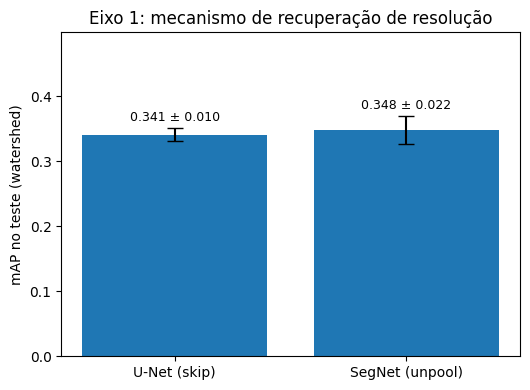

In [92]:
map_eixo1 = resumo(modelos_eixo1, map_teste)

print(f"{'decoder':16s} | mAP teste")
for nome, valores in map_eixo1.items():
    print(f"{nome:16s} | {valores.mean():.3f} ± {valores.std():.3f}")

plotar_ablacao(map_eixo1, "mAP no teste (watershed)", "Eixo 1: mecanismo de recuperação de resolução")

### 3.2 Eixo 2 — função de perda

CE → CE balanceada (α) → focal (γ) → focal balanceada, com γ ∈ {0, 1, 2, 5} (slides 73–79). Uma única classe implementa todas: com γ = 0 e sem α é a CE; α são os pesos por classe da Parte 2 (frequência mediana); γ > 0 reduz o peso dos pixels fáceis, que aqui são quase todos fundo e interior.

O desbalanceamento é severo — a fronteira é uma fração pequena dos pixels — então além do mAP medimos o **recall da classe fronteira**: é onde a perda deveria agir, e é o que o watershed precisa para separar vizinhos.

In [93]:
class FocalLoss(nn.Module):
    """γ = 0 sem α: CE. α: pesos por classe (CE balanceada, normalizada como a CrossEntropyLoss do torch). γ > 0: focal."""
    def __init__(self, gamma=0.0, alpha=None):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha

    def forward(self, logits, alvo):
        log_prob = torch.log_softmax(logits, dim=1).gather(1, alvo.unsqueeze(1)).squeeze(1)
        perda = -(1 - log_prob.exp()) ** self.gamma * log_prob
        if self.alpha is None:
            return perda.mean()
        pesos = self.alpha[alvo]
        return (pesos * perda).sum() / pesos.sum()

unet_3c = lambda: UNetPequena(n_saidas=3)

configs_eixo2 = {
    "CE": (unet_3c, FocalLoss(gamma=0)),
    "CE balanceada": (unet_3c, FocalLoss(gamma=0, alpha=pesos_classe)),
    "focal γ=1": (unet_3c, FocalLoss(gamma=1)),
    "focal γ=2": (unet_3c, FocalLoss(gamma=2)),
    "focal γ=5": (unet_3c, FocalLoss(gamma=5)),
    "focal bal. γ=2": (unet_3c, FocalLoss(gamma=2, alpha=pesos_classe)),
}

inicio = time.time()
modelos_eixo2 = ablacao(configs_eixo2)
print(f"\nEixo 2 em {(time.time() - inicio) / 60:.1f} min")

CE                     | seed 0 | melhor val mAP 0.507
CE                     | seed 1 | melhor val mAP 0.501
CE balanceada          | seed 0 | melhor val mAP 0.354
CE balanceada          | seed 1 | melhor val mAP 0.353
focal γ=1              | seed 0 | melhor val mAP 0.509
focal γ=1              | seed 1 | melhor val mAP 0.501
focal γ=2              | seed 0 | melhor val mAP 0.499
focal γ=2              | seed 1 | melhor val mAP 0.498
focal γ=5              | seed 0 | melhor val mAP 0.495
focal γ=5              | seed 1 | melhor val mAP 0.496
focal bal. γ=2         | seed 0 | melhor val mAP 0.387
focal bal. γ=2         | seed 1 | melhor val mAP 0.348

Eixo 2 em 22.6 min


perda            | mAP teste      | recall fronteira
CE               | 0.473 ± 0.001 | 0.494 ± 0.023
CE balanceada    | 0.345 ± 0.002 | 0.860 ± 0.021
focal γ=1        | 0.475 ± 0.007 | 0.514 ± 0.010
focal γ=2        | 0.466 ± 0.006 | 0.517 ± 0.017
focal γ=5        | 0.467 ± 0.006 | 0.527 ± 0.010
focal bal. γ=2   | 0.361 ± 0.027 | 0.852 ± 0.019


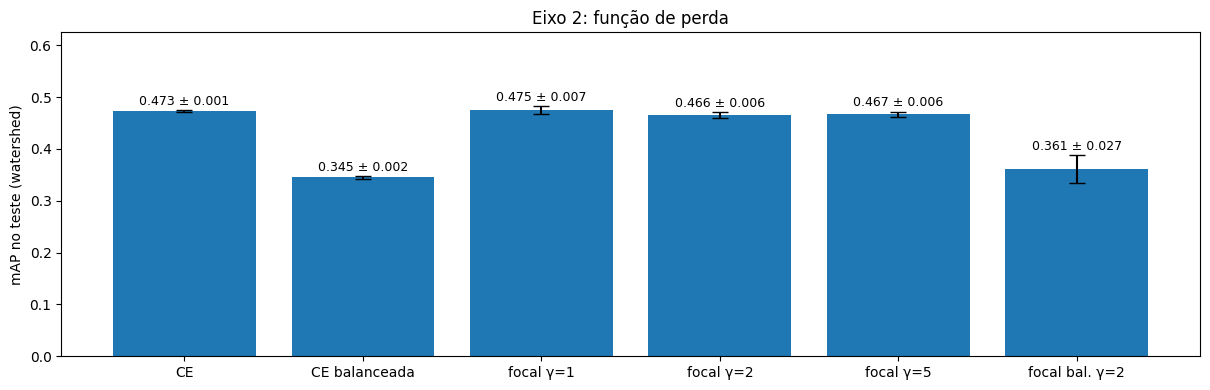

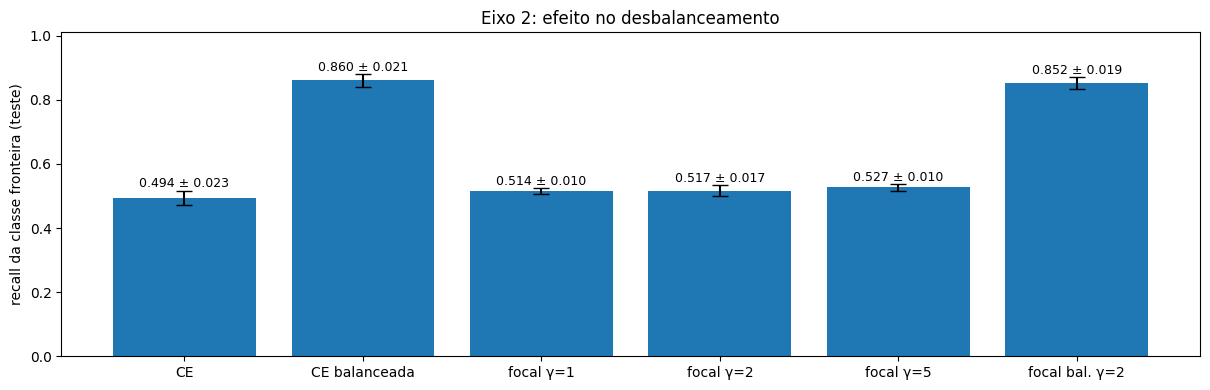

In [94]:
map_eixo2 = resumo(modelos_eixo2, map_teste)
recall_eixo2 = resumo(modelos_eixo2, recall_fronteira)

print(f"{'perda':16s} | mAP teste      | recall fronteira")
for nome in configs_eixo2:
    print(f"{nome:16s} | {map_eixo2[nome].mean():.3f} ± {map_eixo2[nome].std():.3f} | {recall_eixo2[nome].mean():.3f} ± {recall_eixo2[nome].std():.3f}")

plotar_ablacao(map_eixo2, "mAP no teste (watershed)", "Eixo 2: função de perda")
plotar_ablacao(recall_eixo2, "recall da classe fronteira (teste)", "Eixo 2: efeito no desbalanceamento")

**Leitura.** No Eixo 1 a diferença entre os decoders deve concentrar-se nos limiares altos de IoU e na fronteira, que é fina: a skip connection entrega detalhe de resolução plena que o unpooling só reconstrói parcialmente. No Eixo 2 a pergunta é se o mAP acompanha o recall da fronteira: balancear ou focalizar aumenta o recall, mas a partir de certo ponto a rede passa a prever fronteira demais e os interiores encolhem ou se partem — marcadores a mais e mAP menor. É esse ponto de virada, e não o recall máximo, que define a perda do modelo final.

## Parte 4

imagem: (384, 384) | objetos verdadeiros: 45


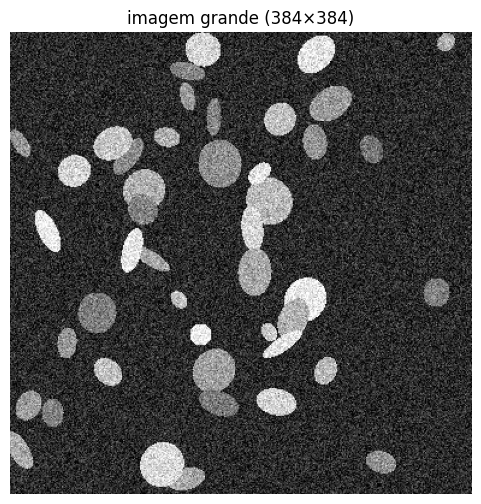

In [24]:
rng_big = np.random.default_rng(123)
imagem_grande, inst_grande = gerar_amostra(size=384, min_elipses=45, max_elipses=70, rng=rng_big)
print("imagem:", imagem_grande.shape, "| objetos verdadeiros:", len(np.unique(inst_grande)) - 1)

plt.figure(figsize=(6, 6))
plt.imshow(imagem_grande, cmap="gray")
plt.axis("off")
plt.title("imagem grande (384×384)")
plt.show()

In [25]:
def posicoes_tiles(H, W, tile, passo):
    ys = list(range(0, H - tile + 1, passo)); ys += [H - tile] if ys[-1] != H - tile else []
    xs = list(range(0, W - tile + 1, passo)); xs += [W - tile] if xs[-1] != W - tile else []
    return ys, xs

def prever_logits_tile(modelo_w, patch):
    x = torch.from_numpy(patch).unsqueeze(0).unsqueeze(0).to(device)

    with torch.no_grad():
        # logits (3, tile, tile)
        return modelo_w(x)[0].cpu()

def inferir_ingenuo(modelo_w, imagem, tile=128, passo=96):
    H, W = imagem.shape
    resultado = np.zeros((H, W), np.int32)
    prox = 1

    for y in posicoes_tiles(H, W, tile, passo)[0]:
        for x in posicoes_tiles(H, W, tile, passo)[1]:
            classes = prever_logits_tile(modelo_w, imagem[y:y+tile, x:x+tile]).argmax(0).numpy()
            inst_local = decodificar_watershed(classes)
            alvo = resultado[y:y+tile, x:x+tile]

            for idl in np.unique(inst_local):
                if idl == 0:
                    continue

                # cola onde ainda está vazio
                escrever = (inst_local == idl) & (alvo == 0)

                if escrever.any():
                    # cada pedaço vira ID novo
                    alvo[escrever] = prox; prox += 1

    return resultado

print("Inferência ingênua pronta.")


Inferência ingênua pronta.


In [26]:
def inferir_corrigido(modelo_w, imagem, tile=128, passo=96):
    H, W = imagem.shape

    # acumula as probabilidades das 3 classes
    soma = np.zeros((3, H, W), np.float32)
    cont = np.zeros((H, W), np.float32)

    # quantos tiles cobriram cada pixel
    ys, xs = posicoes_tiles(H, W, tile, passo)

    for y in ys:
        for x in xs:
            logits = prever_logits_tile(modelo_w, imagem[y:y+tile, x:x+tile])
            probs  = torch.softmax(logits, dim=0).numpy()
            soma[:, y:y+tile, x:x+tile] += probs
            cont[y:y+tile, x:x+tile] += 1

    # média nas sobreposições
    classes_grande = (soma / np.maximum(cont, 1e-6)).argmax(0)
    return decodificar_watershed(classes_grande)

print("Inferência corrigida pronta.")

Inferência corrigida pronta.


objetos verdadeiros : 45
ingênuo (per-tile) :  82 objetos | mAP 0.379
corrigido (global) :  80 objetos | mAP 0.410


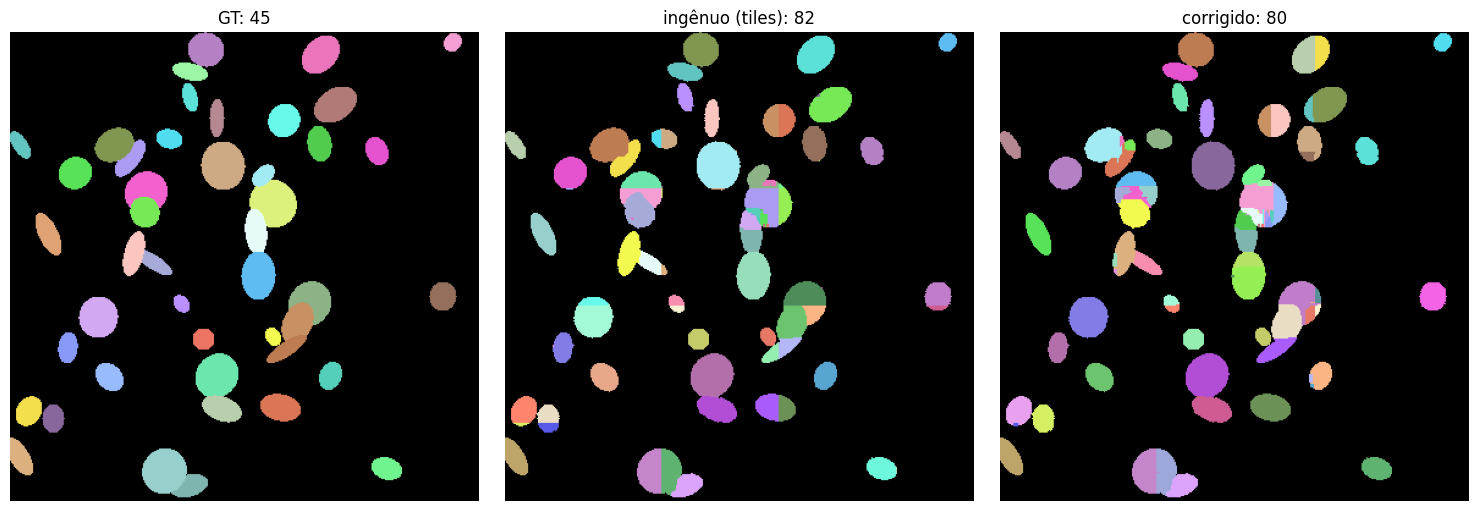

In [28]:
pred_ingenuo = inferir_ingenuo(modelo_w, imagem_grande)
pred_corrigido = inferir_corrigido(modelo_w, imagem_grande)

def map_imagem(pred, gt):
    iou, _, _ = matriz_iou(pred, gt)

    return np.mean([(lambda r: r[0]/(r[0]+r[1]+r[2]) if sum(r) > 0 else 0)(matching_guloso(iou, t)) for t in np.arange(0.5, 1.0, 0.05)])

n_gt = len(np.unique(inst_grande)) - 1
print(f"objetos verdadeiros : {n_gt}")
print(f"ingênuo (per-tile) : {len(np.unique(pred_ingenuo))-1:3d} objetos | mAP {map_imagem(pred_ingenuo, inst_grande):.3f}")
print(f"corrigido (global) : {len(np.unique(pred_corrigido))-1:3d} objetos | mAP {map_imagem(pred_corrigido, inst_grande):.3f}")

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(colorir_instancias(inst_grande))
ax[0].set_title(f"GT: {n_gt}")
ax[0].axis("off")

ax[1].imshow(colorir_instancias(pred_ingenuo))
ax[1].set_title(f"ingênuo (tiles): {len(np.unique(pred_ingenuo))-1}")
ax[1].axis("off")

ax[2].imshow(colorir_instancias(pred_corrigido))
ax[2].set_title(f"corrigido: {len(np.unique(pred_corrigido))-1}")
ax[2].axis("off")

plt.tight_layout()
plt.show()

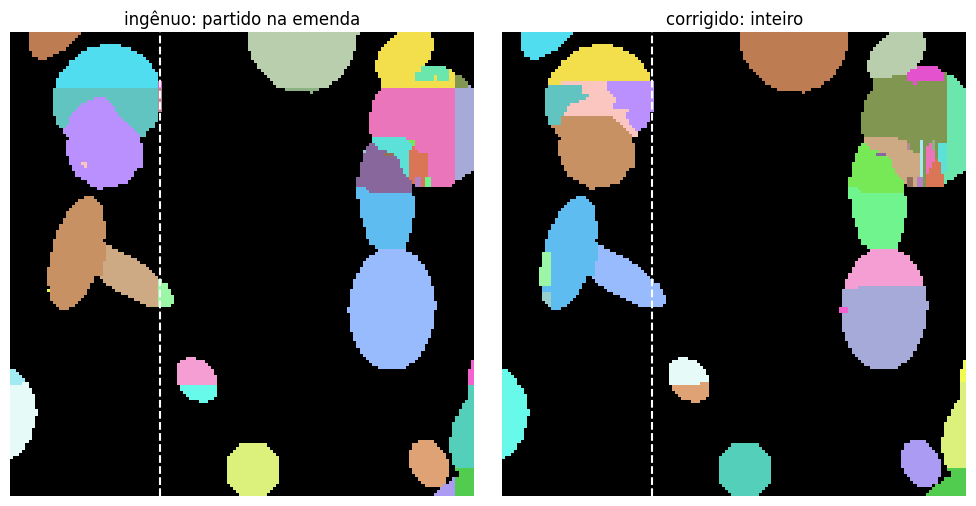

In [29]:
y0, x0, s = 110, 80, 150
seam = 128 - x0

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(colorir_instancias(pred_ingenuo[y0:y0+s, x0:x0+s]))
ax[0].axvline(seam, color="white", ls="--"); ax[0].set_title("ingênuo: partido na emenda")
ax[0].axis("off")

ax[1].imshow(colorir_instancias(pred_corrigido[y0:y0+s, x0:x0+s]))
ax[1].axvline(seam, color="white", ls="--")
ax[1].set_title("corrigido: inteiro")
ax[1].axis("off")

plt.tight_layout()
plt.show()

## Parte 5

In [31]:
def campo_receptivo(camadas):
    """camadas: lista de (nome, kernel, stride). Aplica a recorrência dos slides 35-38."""
    rf, pulo = 1, 1
    print(f"{'camada':13s} | RF  | pulo")

    for nome, k, s in camadas:
        # a convolução amplia o campo
        rf  += (k - 1) * pulo
        # o pooling amplia o passo
        pulo *= s
        print(f"{nome:13s} | {rf:3d} | {pulo}")

    return rf

encoder = [
    ("conv 3x3", 3, 1), ("conv 3x3", 3, 1),
    ("maxpool 2", 2, 2),
    ("conv 3x3", 3, 1), ("conv 3x3", 3, 1),
    ("maxpool 2", 2, 2),
    ("conv 3x3", 3, 1), ("conv 3x3", 3, 1),
]

RF = campo_receptivo(encoder)
print(f"\n>>> Campo receptivo do encoder = {RF} px")

camada        | RF  | pulo
conv 3x3      |   3 | 1
conv 3x3      |   5 | 1
maxpool 2     |   6 | 2
conv 3x3      |  10 | 2
conv 3x3      |  14 | 2
maxpool 2     |  16 | 4
conv 3x3      |  24 | 4
conv 3x3      |  32 | 4

>>> Campo receptivo do encoder = 32 px


eixo maior: mediana=31px, máx=46px
45% dos objetos são MAIORES que o campo receptivo (32px)


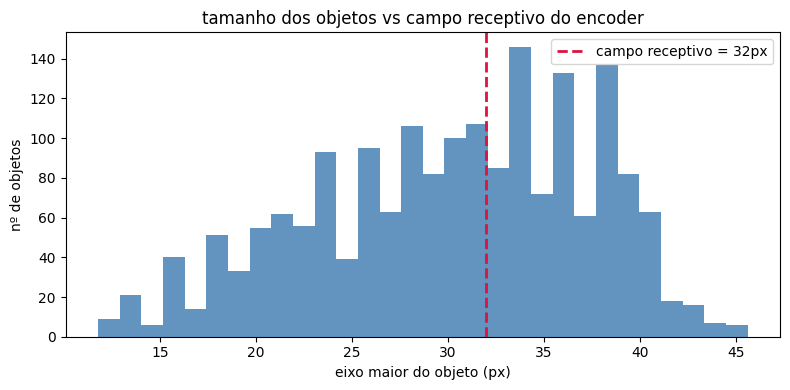

In [32]:
rng = np.random.default_rng(0)
eixos_maior = []

for _ in range(150):
    _, inst = gerar_amostra(rng=rng)

    for p in regionprops(inst):
        # maior extensão do objeto
        eixos_maior.append(p.axis_major_length)

eixos_maior = np.array(eixos_maior)

frac = 100 * (eixos_maior > RF).mean()
print(f"eixo maior: mediana={np.median(eixos_maior):.0f}px, máx={eixos_maior.max():.0f}px")
print(f"{frac:.0f}% dos objetos são MAIORES que o campo receptivo ({RF}px)")

plt.figure(figsize=(8, 4))
plt.hist(eixos_maior, bins=30, color="steelblue", alpha=0.85)
plt.axvline(RF, color="crimson", ls="--", lw=2, label=f"campo receptivo = {RF}px")
plt.xlabel("eixo maior do objeto (px)")
plt.ylabel("nº de objetos")
plt.title("tamanho dos objetos vs campo receptivo do encoder")
plt.legend()
plt.tight_layout()
plt.show()